In [1]:
# Copyright (c) Meta Platforms, Inc. and affiliates.
# and David Edel
# This source code is licensed under the MIT license found in the
# LICENSE file in the root directory of this source tree.

"""Simple example of QAT using DDP (ResNet on CIFAR-10)
Adapted from https://github.com/akamaster/pytorch_resnet_cifar10"""
# os.environ["TORCH_LOGS"]="recompiles"
import torch
import torch._dynamo

torch._dynamo.config.cache_size_limit = 64
torch._dynamo.config.recompile_limit = 64
# torch._dynamo.config.verbose = True
# torch._inductor.config.debug = True

import json
import torch.nn as nn
from torchvision import transforms as T
from torch import optim

import itertools

from model import resnet
from model.resnet import ResNet,BasicBlock
import wandb
import time


from tqpmod.parq_utils import (
    NORM_LAYERS,
    get_param_groups,
    split_param_groups,
    create_data_loaders,
)
from tqpmod.tqp_optimizer_scale_train import TQPS
# from tqpmod.softbinning import SoftBinning # replace with custom
from tqpmod.logging_utils import init_loger_and_folder
from tqpmod.train_eval import train_epoch, evaluate

import math # for nan check

DEVICE = torch.device("cuda:0")
torch.set_float32_matmul_precision("high")  # improves matmul speed
import matplotlib.pyplot as plt


In [2]:
class SoftBinningScale:
    def __init__(self, bins=3):
        if bins < 3 or bins % 2 != 1:
            raise ValueError("bins must be odd >= 3")
        self.bins = bins // 2
        self.max = self.bins

    @torch.no_grad()
    @torch.compile()
    def call_test(self, x: torch.Tensor):
        x = torch.abs(x)
        y = 1 - self.max + x
        mask = x < self.max
        y[mask] = x[mask] - torch.floor(x[mask])
        y = y * torch.abs(1 - y)
        return y

    def compute_xright_quantile(self, x: torch.Tensor):
        x, _ = x.clone().detach().flatten().sort()
        third = x[x.shape[0] // 3]
        two_thirds = x[int(x.shape[0] * (2 / 3))]
        return third.abs() + two_thirds.abs()


soft_binning = SoftBinningScale(3)

In [3]:
@torch.compile()
@torch.no_grad()
def calc_reg_loss_scale_layer(
    optimizer:TQPS,
    soft_binning: SoftBinningScale,
    n_params,
    device=torch.device("cuda:0"),
    M=1,
    beta=5e-4,
    compute_per_layer_share_done = False
):
    """
    returns tuple of:
    avg_reg_loss, a norm, %done
    """

    reg_loss = torch.zeros((), device=device, requires_grad=False)
    quantized_params = torch.zeros(
        (), device=device, requires_grad=False, dtype=torch.int64
    )
    norm = torch.zeros((), device=device, requires_grad=False)
    per_layer_share_done = torch.zeros((len(optimizer.regularized_params)))
    for i, param in enumerate(optimizer.regularized_params):
        
        reg_loss += soft_binning.call_test(param).sum().detach()

        calc_param = param.detach()
        quantized_this_param = (
            (abs(calc_param - calc_param.round().clip(-M, M)) < (beta / 2))
            .sum()
            .to(torch.int64))
        quantized_params += quantized_this_param
        
        per_layer_share_done[i] = quantized_this_param / param.numel()
        norm += param.norm().detach()

    return (reg_loss / n_params).item(), norm.sqrt().item(), (quantized_params / n_params).item(), per_layer_share_done

In [4]:
@torch.no_grad()
def factor_function_test(params):
    return (params.flatten().std() * 2 * 0.5) * torch.ones((params.shape[0],),device=params.device)
    # the 0.5 and 2 cancel, but leave them in because we could adjust the params for this

(array([100., 100., 100., 100., 100., 100., 100., 100., 100., 100.]),
 array([-1.72945428, -1.3835634 , -1.03767252, -0.69178176, -0.34589088,
         0.        ,  0.34589076,  0.69178176,  1.03767252,  1.38356328,
         1.72945428]),
 <BarContainer object of 10 artists>)

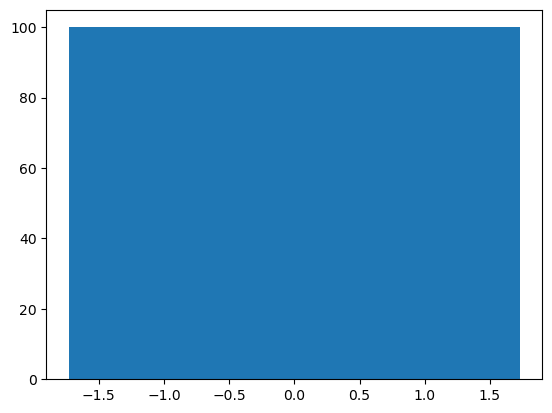

In [5]:
x = torch.linspace(-3.5,3.5,1000)
fac = factor_function_test(x)
plt.hist(x / fac)

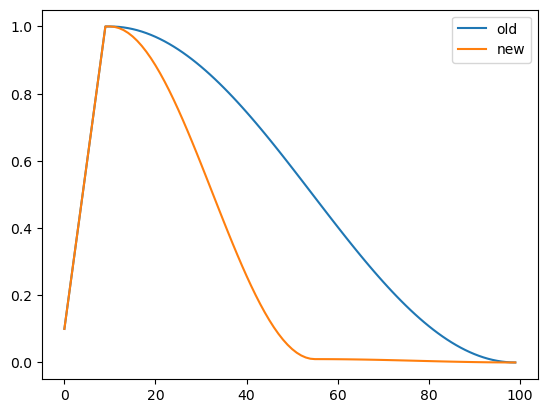

In [6]:
import numpy as np
num_epochs = 100
lr_warmup_epochs = 10
num_epochs_lr_schedule = 99
new_cos_epoch = 55
def get_lr_factor(epoch):
    if epoch < lr_warmup_epochs:
        return (epoch + 1) / lr_warmup_epochs
    elif epoch > num_epochs_lr_schedule:
        return get_lr_factor(num_epochs_lr_schedule)
    else:
        return max(
            [
                0.5
                * (
                    1
                    + np.cos(
                        np.pi
                        * (epoch - lr_warmup_epochs)
                        / (num_epochs_lr_schedule - lr_warmup_epochs)
                    )
                ) ,
                1e-9,
            ]
        )

percentage_new_cos = 0.01

def get_lr_factor_double_cos(epoch):
    if epoch < lr_warmup_epochs:
        return (epoch + 1) / lr_warmup_epochs
    elif epoch < new_cos_epoch:
        return max(
            [
                ( 0.5
                * (
                    1
                    + np.cos(
                        np.pi
                        * (epoch - lr_warmup_epochs)
                        / (new_cos_epoch - lr_warmup_epochs)
                    )
                ) ) * (1 - percentage_new_cos) + percentage_new_cos,
                1e-9,
            ]
        )
    else:
        return 0.5 * percentage_new_cos * (1 + np.cos(np.pi * (epoch-new_cos_epoch)/ (num_epochs - new_cos_epoch) ))
            
x = np.arange(100)
y = [get_lr_factor(xi) for xi in x]
y_new = [get_lr_factor_double_cos(xi) for xi in x]
plt.plot(x,y,label="old")
plt.plot(x,y_new,label="new")
plt.legend()

In [7]:
from tqpmod.model_utils import ScaleLayer
from tqpmod.tqp_optimizer import equisplit


@torch.no_grad()
def inject_scale_layers_bias_wd(
    model: nn.Module,
    param_dicts_list: list,
    dtype_target=torch.float32,
    dtype_calc=torch.float64,
    factor_function=equisplit,
    factor_function_args=(),
    learning_rate=0.1,
    weight_decay=0.02,
    scale_grad = True,
):
    for name, child in model.named_children():
        # Check for both Linear and Conv2d
        if isinstance(child, (nn.Linear, nn.Conv2d)):
            # Create a sequence: Original Layer -> Test Layer

            factors = factor_function(
                child.weight.to(dtype_calc), *factor_function_args
            )
            factors = factors.reshape((-1, 1))

            scale_shape = (1, child.weight.shape[0])

            if isinstance(child, nn.Conv2d):
                scale_shape = (*scale_shape, 1, 1)  # append 1,1 to shape for conv
                factors = factors.reshape((*factors.shape, 1, 1))

            child.weight.copy_(
                ((child.weight.detach().to(dtype_calc) / factors).to(dtype_target)).to(
                    dtype_target
                )
            )
            if child.bias is not None:
                if isinstance(child, nn.Conv2d):
                    print("TODO: check if this bias is correct for conv2d bias")
                child.bias.div_(factors.flatten())
                param_dicts_list.append(  # **2 for sgd
                {
                    "params": [child.bias],
                    "weight_decay": (weight_decay * (factors.mean() ** 2)).to(dtype_target),
                    "lr": (learning_rate * ((1 / factors.mean()) ** 2)).to(
                        dtype_target
                    ),
                }
            )
            scale = ScaleLayer(scale_shape).to(child.weight.device)
            scale.scale.requires_grad=scale_grad
            scale.scale.mul_(factors.to(dtype_target).reshape(scale_shape))
            new_block = nn.Sequential(child, scale)
            
            # Replace the attribute on the model
            setattr(model, name, new_block)
            param_dicts_list.append(  # **2 for sgd
                {
                    "params": [child.weight],
                    "quant_bits": 0,
                    "weight_decay": (weight_decay * (factors.mean() ** 2)).to(dtype_target),
                    "lr": (learning_rate * ((1 / factors.mean()) ** 2)).to(
                        dtype_target
                    ),
                }
            )
            

        else:
            # Recurse for nested modules (like Bottlenecks in ResNet)

            inject_scale_layers_bias_wd(
                child,
                param_dicts_list,
                dtype_target=dtype_target,
                dtype_calc=dtype_calc,
                factor_function=factor_function,
                factor_function_args=factor_function_args,
                learning_rate=learning_rate,
                weight_decay=weight_decay,
                scale_grad=scale_grad
            )

@torch.no_grad()
def rebalance_layers_bias_wd(
    model: nn.Module,
    param_dict: dict[nn.Parameter,dict],
    lr_schedule:torch.optim.lr_scheduler.LRScheduler,
    optimizer: torch.optim,
    dtype_target=torch.float32,
    dtype_calc=torch.float64,
    factor_function=equisplit,
    factor_function_args=(),
):
    for name, child in model.named_children():
        if isinstance(child,nn.Sequential) and (len(child) == 2) and isinstance(child[1],ScaleLayer):
            linear:nn.Linear | nn.Conv2d = child[0]
            scale:ScaleLayer = child[1]
            scale_shape = scale.scale.shape
            # if "conv1" in name:
            #     bn = model.bn1                
            # elif "conv2" in name:
            #     bn = model.bn2
            # else:
            #     # for the linear layer at the end:
            #     # bn = nn.BatchNorm2d(torch.numel(scale_shape)) # dummy batchnorm that gets destroyed at function close.
            #     pass
            # bn:nn.BatchNorm2d
            

            
            factors = factor_function(
                linear.weight.to(dtype_calc), *factor_function_args
            )
            factors = factors.reshape((-1, 1)).to(dtype_target)

            if isinstance(linear, nn.Conv2d):
                factors = factors.reshape((*factors.shape, 1, 1))

            linear.weight.copy_(
                (linear.weight.detach().to(dtype_calc) / factors).to(dtype_target)
            )
            param_dict[linear.weight]["group"]["lr"] = param_dict[linear.weight]["group"]["lr"] * ((1 / factors.mean()) ** 2).to(
                        dtype_target
                    ).item()
            index_weight = param_dict[linear.weight]["index"]
            lr_schedule.base_lrs[index_weight]=lr_schedule.base_lrs[index_weight] * ((1 / factors.mean()) ** 2).to(
                        dtype_target
                    )
            
            param_dict[linear.weight]["group"]["weight_decay"] = param_dict[linear.weight]["group"]["weight_decay"] * (factors.mean() ** 2).to(
                        dtype_target
                    ).item()
            optimizer.base_optimizer.state[linear.weight]["momentum_buffer"].mul_(factors)

            if linear.bias is not None:
                if isinstance(linear, nn.Conv2d):
                    print("TODO: check if this bias is correct for conv2d bias")
                linear.bias.div_(factors.flatten())
                param_dict[linear.bias]["group"]["lr"] = param_dict[linear.bias]["group"]["lr"] * ((1 / factors.mean()) ** 2).to(
                        dtype_target
                    ).item()
                index_bias = param_dict[linear.bias]["index"]
                lr_schedule.base_lrs[index_bias]=lr_schedule.base_lrs[index_bias] * ((1 / factors.mean()) ** 2).to(
                        dtype_target
                    )
                optimizer.base_optimizer.state[linear.bias]["momentum_buffer"].mul_(factors.flatten())
                param_dict[linear.bias]["group"]["weight_decay"] = param_dict[linear.bias]["group"]["weight_decay"] * (factors.mean() ** 2).to(
                        dtype_target
                    ).item()    
            scale.scale.mul_(factors.reshape(scale_shape))

            # BatchNorm scale:
            # stays the same

            # TODO: maybe also scale: scale lr.
        else:
            rebalance_layers_bias_wd(
                child,
                param_dict=param_dict,
                lr_schedule=lr_schedule,
                optimizer=optimizer,
                dtype_target=dtype_target,
                dtype_calc=dtype_calc,
                factor_function=factor_function,
                factor_function_args=factor_function_args,
            )

In [8]:
from typing import Any, Callable


def longrun_scale_layer(
    beta, train_params: dict[str, Any], run_name: str = "ScaleLayerTrain"
):
    try:
        logger, folder = init_loger_and_folder(run_name)
        history = {
            "train_loss": [],
            "train_acc": [],
            "test_loss": [],
            "test_acc": [],
            "reg_loss": [],
            "norm": [],
            "per_layer_share_done": [],
            "beta": [],
        }

        # ALL these hyperparams could get overwritten by train_params
        num_epochs = 600  # 1000  # like 310
        num_epochs_lr_schedule = 599  # 999 # 300
        learning_rate = 0.1
        weight_decay = 2e-4

        lr_warmup_epochs = 10
        percentage_new_cos = 0.1
        new_cos_epoch = (num_epochs - lr_warmup_epochs) / 2  # gets overwritten below

        REG_wait_epochs = 55  # 55

        SEED = torch.randint(0, 10000, (1,))
        batch_size = 64

        inject_scales = True

        if train_params is not None:
            num_epochs = train_params.get("num_epochs", num_epochs)
            num_epochs_lr_schedule = num_epochs - 1
            num_epochs_lr_schedule = train_params.get(
                "num_epochs_lr_schedule", num_epochs_lr_schedule
            )
            learning_rate = train_params.get("learning_rate", learning_rate)
            weight_decay = train_params.get("weight_decay", weight_decay)
            lr_warmup_epochs = train_params.get("lr_warmup_epochs", lr_warmup_epochs)
            percentage_new_cos = train_params.get(
                "percentage_new_cos", percentage_new_cos
            )
            new_cos_epoch = (
                num_epochs - lr_warmup_epochs
            ) / 2  # Overwrite default based on provided params
            new_cos_epoch = train_params.get("new_cos_epoch", new_cos_epoch)
            REG_wait_epochs = train_params.get("REG_wait_epochs", REG_wait_epochs)
            SEED = train_params.get("SEED", SEED)

            batch_size = train_params.get("batch_size", batch_size)

            inject_scales = train_params.get("inject_scales", inject_scales)

        torch.manual_seed(SEED)

        train_loader, val_loader = create_data_loaders(
            "~/data",
            batch_size,
            11,
            False,
            SEED,
        )
        steps_per_epoch = len(train_loader)

        # define loss function (criterion) and optimizer
        scaler = torch.amp.GradScaler("cuda")
        label_smoothing = 0.1
        criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing).to(DEVICE)  #
        model = ResNet(BasicBlock, [3, 3, 3], skip_kaiming_init=True)
        param_groups = []
        # TOD:
        rest_group = []
        names = {
            param: name for name, param in model.named_parameters()
        }  # for debugging

        if inject_scales:
            inject_scale_layers_bias_wd(
                model,
                param_groups,
                factor_function=factor_function_test,
                learning_rate=learning_rate,
                weight_decay=weight_decay,
                scale_grad=False,
            )
        else: # disables scale train
            param_groups.append(
                {
                    "params": [param for param in model.parameters() if len(param.shape) > 1],
                    "quant_bits": 32,
                    "weight_decay": weight_decay,
                    "learning_rate": learning_rate,
                }
            )

        model = model.to(DEVICE)
        # specify number of quantization bits for different parameter groups

        # None indicates that it will need to get updated before starting training
        # param_groups_quant = [{"params:":[param],"quant_bits":0,"weight_decay": None,learning_rate:None} for param in params_quant]
        param_groups_list = []
        for param_group in param_groups:
            param_groups_list.extend([id(param) for param in param_group["params"]])

        for name, param in model.named_parameters():
            if id(param) not in param_groups_list:
                rest_group.append(param)
        param_groups.append(
            {
                "params": rest_group,
                "weight_decay": weight_decay,
                "lr": learning_rate,
            }  # use defalut lr
        )
        print("REST GROUP is using WD, check if you want that")
        def build_lr_factor(lr_warmup_epochs, num_epochs_lr_schedule=None):
            num_epochs_lr_schedule = num_epochs_lr_schedule or (num_epochs - 1)

            def get_lr_factor(epoch):
                if epoch < lr_warmup_epochs:
                    return (epoch + 1) / lr_warmup_epochs
                elif epoch > num_epochs_lr_schedule:
                    return get_lr_factor(num_epochs_lr_schedule)
                else:
                    return max(
                        [
                            0.5
                            * (
                                1
                                + np.cos(
                                    np.pi
                                    * (epoch - lr_warmup_epochs)
                                    / (num_epochs_lr_schedule - lr_warmup_epochs)
                                )
                            ),
                            1e-9,
                        ]
                    )

            return get_lr_factor

        get_lr_factor: Callable = build_lr_factor(
            lr_warmup_epochs, num_epochs_lr_schedule
        )


        base_optimizer = torch.optim.SGD(
            param_groups,
            learning_rate,
            momentum=0.9,
            weight_decay=weight_decay,
            fused=True,  # test
        )
        lr_scheduler = optim.lr_scheduler.LambdaLR(
            base_optimizer, lr_lambda=get_lr_factor
        )

        best_acc = 0.0
        best_reg_loss = float("inf")

        optimizer = TQPS(
            base_optimizer,
            len(train_loader),
            reg_wait_epochs=REG_wait_epochs,
            regularization_epochs=num_epochs,
            beta=beta,
            logger=logger,
        )
        optimizer.base_optimizer.zero_grad()

        n_reg_params = sum([torch.numel(x) for x in optimizer.regularized_params])
        model = torch.compile(model, mode="max-autotune", fullgraph=True, dynamic=False)
        torch.save(
            {
                "epoch": 0,
                "num_epochs": num_epochs,
                "SEED": SEED,
                "label_smoothing": label_smoothing,
                "REG_wait_epochs": REG_wait_epochs,
                "lr_warmup_epochs": lr_warmup_epochs,
                "num_epochs_lr_schedule": num_epochs_lr_schedule,
                "model_state_dict": model.state_dict(),
                "base_optimizer_state_dict": base_optimizer.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "current_acc": 0,
                "reg_loss": torch.inf,
                "lr_schedule": lr_scheduler.state_dict(),
                "scaler": scaler.state_dict(),
                "history": json.dumps(history),
                "best_reg_loss": best_reg_loss,
                "best_acc": best_acc,
                "batch_size": batch_size,
            },
            f"{folder}/init_pre_train.pth",
        )
        with wandb.init(
            project="ResNet-TQP",
            name=f"{run_name}-{beta}",
            config={
                "architecture": "ResNet20",
                "load_state": False,
                "Use Pretrained": f"{False}",
                "dataset": "CIFAR-10",
                "seed": SEED,
                "num_epochs": num_epochs,
                "batch_size": batch_size,
                "optimizer": base_optimizer.__class__.__name__,
                "start_lr": learning_rate,
                "lr_warmup_epochs": lr_warmup_epochs,
                "weight_decay": weight_decay,
                "beta": beta,
                "reg_wait_epochs": REG_wait_epochs,
                "label_smoothing": label_smoothing,
                "note": "every epoch factor, dont wait",
            },
            # mode="disabled"
        ) as run:

            for epoch in range(0, num_epochs):
                # for epoch in range(start_epoch, 350):
                # for epoch in range(num_epochs, num_epochs+20):
                start_time = time.time()
                logger.info(
                    f"\nEpoch [{epoch+1}/{num_epochs}] | LR: {base_optimizer.param_groups[0]['lr']:.10f}"
                )

                #if epoch == num_epochs - 1:
                #    optimizer.set_final_beta()
                #    logger.warning("DISABLED GRAD ON REG-PARAMS")
                #    logger.info("overwrote beta to 1 for final epoch")

                # Train
                train_loss, train_acc = train_epoch(
                    model,
                    train_loader,
                    criterion,
                    optimizer,
                    scaler,
                    DEVICE,
                    epoch == 10,
                    epoch,
                    amp=True,
                )
                # TODO: compute change rate

                # keep REBALANCE_LAYERS and LR_SCHEDULER.STEP together, because we need to avoid training after rebalancing before updating learning rates
                if epoch == 44:  # TODO: check one off error
                    param_dict = {
                        group["params"][0]: {"index": index, "group": group}
                        for index, group in enumerate(optimizer.param_groups)
                        if len(group["params"]) == 1
                    }
                    # param_dict is needed because rebalance needs to know each parameter_groups index in the lr_schedulers base_lrs list.
                    # the group itself is also needed to adjust weight decay.
                    rebalance_layers_bias_wd(
                        model,
                        param_dict,
                        lr_scheduler,
                        optimizer,
                        factor_function=factor_function_test,
                    )
                lr_scheduler.step()

                # TODO: think about wd decay with scaled again!!
                # for param_group in optimizer.get_regularized_param_groups():
                #     param_group["weight_decay"] = weight_decay * get_lr_factor(epoch)

                reg_loss, norm, share_done,per_layer_share_done = calc_reg_loss_scale_layer(
                    optimizer, soft_binning, n_reg_params, beta=beta
                )
                # decay beta based on finished_rate
                if epoch > 11 and optimizer.beta != 1.0:
                    new_beta = (1 - share_done) * beta + share_done * (beta * 1e-2)
                    new_beta = min(new_beta, history["beta"][-1])
                    if isinstance(optimizer.beta, torch.Tensor):
                        optimizer.beta.copy_(new_beta)
                    else:
                        optimizer.beta = torch.tensor(
                            new_beta, device=DEVICE, requires_grad=False
                        )
                else:
                    new_beta = beta
                # Save history
                history["beta"].append(new_beta)
                history["train_loss"].append(train_loss)
                history["train_acc"].append(train_acc)

                history["per_layer_share_done"].append(per_layer_share_done.detach().cpu().numpy().tolist())
                logger.info(
                    f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Reg Loss: {reg_loss:.4f}"
                )

                history["reg_loss"].append(reg_loss)
                history["norm"].append(norm)

                to_log = {
                    "lr": torch.tensor(lr_scheduler.get_last_lr()).mean().item(),
                    "epoch": epoch,
                    "train_loss": train_loss,
                    "train_acc": train_acc,
                    "reg_loss": reg_loss,
                    "norm": norm,
                    "beta": optimizer.beta,
                    "share_done": share_done,
                }

                if epoch % 2 == 1:
                    test_loss, test_acc = evaluate(model, val_loader, criterion, DEVICE)
                    history["test_acc"].append(test_acc)
                    history["test_loss"].append(test_loss)
                    logger.info(
                        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%"
                    )
                    to_log.update(
                        {
                            "test_loss": test_loss,
                            "test_acc": test_acc,
                        }
                    )
                    best_acc = max([test_acc, best_acc])

                    # to_log.update({f"change_rate_layer_{i}": cr for i, cr in enumerate(change_rates)})

                    # Save best model
                    if reg_loss < best_reg_loss:
                        best_reg_loss = reg_loss
                        torch.save(
                            {
                                "epoch": epoch,
                                "num_epochs": num_epochs,
                                "SEED": SEED,
                                "label_smoothing": label_smoothing,
                                "REG_wait_epochs": REG_wait_epochs,
                                "lr_warmup_epochs": lr_warmup_epochs,
                                "num_epochs_lr_schedule": num_epochs_lr_schedule,
                                "model_state_dict": model.state_dict(),
                                "base_optimizer_state_dict": base_optimizer.state_dict(),
                                "optimizer_state_dict": optimizer.state_dict(),
                                "current_acc": test_acc,
                                "reg_loss": reg_loss,
                                "lr_schedule": lr_scheduler.state_dict(),
                                "scaler": scaler.state_dict(),
                                "history": json.dumps(history),
                                "best_reg_loss": best_reg_loss,
                                "best_acc": best_acc,
                                "batch_size": batch_size,
                            },
                            f"{folder}/best_reg_loss_model.pth",
                        )
                        logger.info(
                            f"✓ Saved best model with best reg_loss: {best_reg_loss:.3f}, accuracy: {test_acc:.2f}%"
                        )
                    else:
                        logger.info(
                            f"(X) model did not beat reg_loss: {reg_loss:.3f} vs {best_reg_loss:.3f}, accuracy: {test_acc:.2f}%"
                        )
                    # health check:
                    if math.isnan(reg_loss):
                        raise RuntimeError("idk why but reg loss in nan")
                epoch_time = time.time() - start_time
                logger.info(f"Epoch Time: {epoch_time:.2f}s")
                to_log.update({"epoch time:": epoch_time})
                run.log(to_log, step=epoch)
            # wandb context
            # if epoch == 10:
            #     break
    except Exception as e:
        logger.error(f"error: {e}")
    return history, model, optimizer

In [ ]:
print("Rebalance epoch is fixed to 45 in code")
hist, model, optimizer = longrun_scale_layer(
    5e-4, {"num_epochs": 300, "REG_wait_epochs": 5000}, "300_scale_no_reg_no_scale_grad"
)

In [9]:
res = []
for i in range(10):
    hist, model, optimizer = longrun_scale_layer(
        5e-4, {"num_epochs": 300, "REG_wait_epochs": 5000}, "300_scale_no_reg_no_scale_grad_fix_bias_rest_wd"
    )
    res.append(hist["test_acc"][-1])
print(res)

2026-07-12 02:57:56 [WARNING] Starting logging...
/home/david/miniconda3/envs/torch26/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/david/.netrc.


REST GROUP is using WD, check if you want that


wandb: Currently logged in as: david-edel (david-edel-university-heidelberg-germany) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


2026-07-12 02:57:58 [INFO] 
Epoch [1/300] | LR: 0.8725324869
Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 781/781 [00:23<00:00, 32.74it/s]
2026-07-12 02:58:23 [INFO] Train Loss: 1.6701 | Train Acc: 45.23% | Reg Loss: 0.4048
2026-07-12 02:58:23 [INFO] Epoch Time: 25.45s
2026-07-12 02:58:24 [INFO] 
Epoch [2/300] | LR: 1.7450649738
Training: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 781/781 [00:03<00:00, 213.88it/s]
2026-07-12 02:58:27 [INFO] Train Loss: 1.3511 | Train Acc: 62.02% | Reg Loss: 0.6134
Evaluating: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

beta,██▇▇▇▆▆▆▆▆▆▅▄▄▄▄▃▃▃▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
epoch time:,▂▁▁▆▅▇▇▇▆▆▆▆▇▆▆▇▇▆▆█▆▆▆▅▆▆▅▆▆▅▆▅▆▅▅▅▆▆▆▅
lr,▆███▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
norm,▅▆▇▇███▃▃▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁
reg_loss,▄▅▇▇█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
share_done,▁▁▁▁▁▂▂▂▂▃▄▅▅▅▆▆▇▇▇▇▇██▇█▇▇▇▇▇▇██▇███▇██
test_acc,▁▄▄▃▄▅▁▃▄▄▅▄▄▂▅▅▅▅▆▅▆▆▅▆▆▆▆▆▇▇▇▇▇▇▇█████
test_loss,█▆▅█▇▅▄▇▅▄▃▄▃▄▃▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁
train_acc,▁▅▆▆▆▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇████████
+1,...


...

2026-07-12 07:28:18 [WARNING] Starting logging...
/home/david/miniconda3/envs/torch26/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


REST GROUP is using WD, check if you want that


2026-07-12 07:28:20 [INFO] 
Epoch [1/300] | LR: 0.7647616267
Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 781/781 [00:25<00:00, 30.38it/s]
2026-07-12 07:28:46 [INFO] Train Loss: 1.6963 | Train Acc: 43.80% | Reg Loss: 0.4009
2026-07-12 07:28:46 [INFO] Epoch Time: 25.81s
2026-07-12 07:28:46 [INFO] 
Epoch [2/300] | LR: 1.5295232534
Training: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 781/781 [00:05<00:00, 141.01it/s]
2026-07-12 07:28:52 [INFO] Train Loss: 1.3525 | Train Acc: 61.83% | Reg Loss: 0.6087
Evaluating: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

beta,█▇▇▇▇▆▆▆▅▅▃▃▃▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▇█
epoch time:,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
lr,▃▇████▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
norm,▃▅▇█████▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁
reg_loss,▁▅▇█████▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
share_done,▁▁▁▂▂▄▆▆▆▆▆▆▇▇▇███████████████████████▇█
test_acc,▁▃▂▃▅▄▅▅▅▄▅▄▄▆▅▅▅▆▆▅▄▅▆▇▇▇▇▇▇▇▇▇▇███████
test_loss,█▇▆▆▄▄▆▆▄▅▄▄▄▄▃▄▄▅▄▄▅▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁
train_acc,▁▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇█████████
+1,...


[92.79, 93.17, 92.8, 92.71, 92.93, 92.73, 92.44, 93.08, 92.85, 92.72]


In [ ]:
plt.hist(model.conv1[0].weight.data.detach().cpu().flatten() ,bins=35)